<a href="https://colab.research.google.com/github/nabilanisa1504/Pengolahan-Citra/blob/main/Jobsheet_5_Mengukur_Kemiripan_Citra_dan_Penerapannya_Dalam_Pengenalan_Pola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


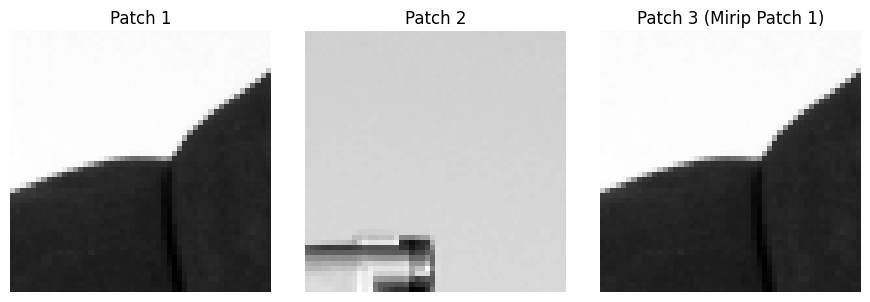

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy.spatial import distance

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350] # Patch dari lokasi berbeda
patch3 = patch1 + 0.1            # Patch1 dengan sedikit perubahan intensitas
patch3 = np.clip(patch3, 0, 1)   # Pastikan nilai tetap di rentang [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil perhitungan
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

# 6. Visualisasi Patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


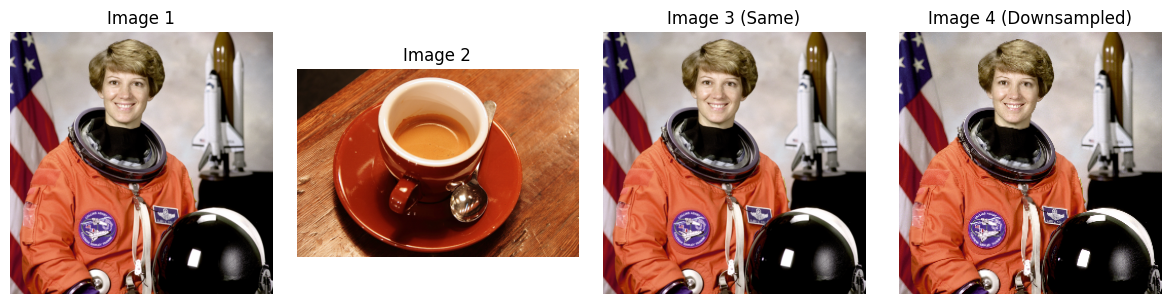

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi (opsional, tapi sering dilakukan)
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Muat dua citra berwarna
try:
    # Gunakan citra berbeda dari skimage atau file Anda
    image1 = data.astronaut()
    image2 = data.coffee()    # Citra yang berbeda
    image3 = data.astronaut() # Citra yang sama (untuk perbandingan)
    image4 = image1[::2, ::2, :] # Versi downsampled dari image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity (1 - Cosine Distance)
# scipy.spatial.distance.cosine menghitung jarak (1 - similarity)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")

# 5. Visualisasi (opsional)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2947
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


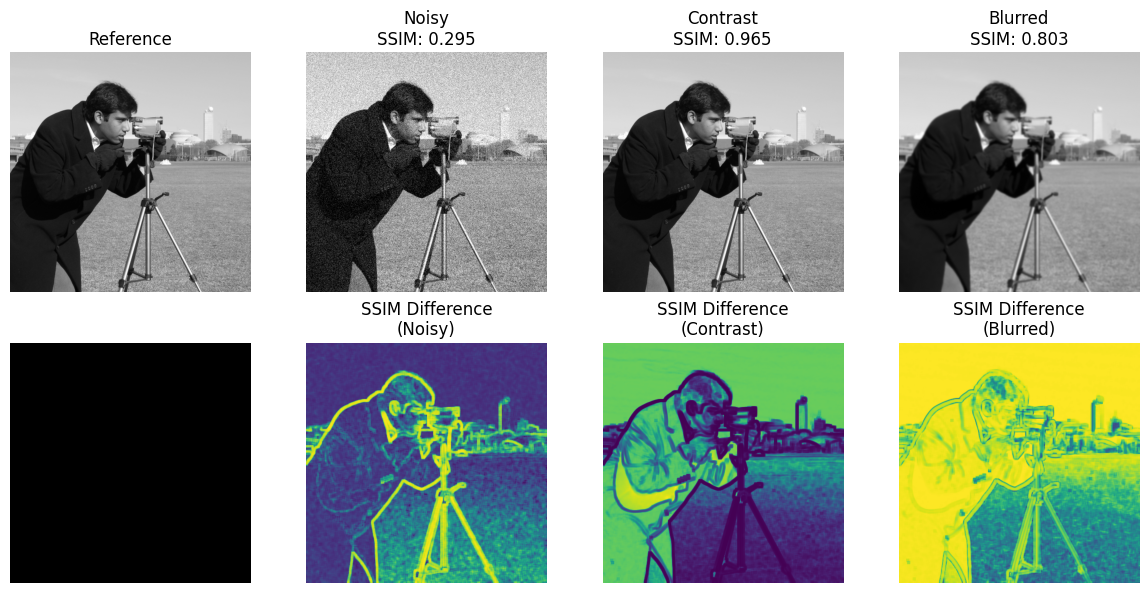

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra yang 'terdistorsi'
# a) Citra yang sama (SSIM harus 1)
image_same = image_ref.copy()

# b) Citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)

# c) Citra dengan kontras berbeda (contoh: dikalikan skalar)
image_contrast = np.clip(image_ref * 0.8, 0, 1)

# d) Citra yang di-blur
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None) # channel_axis=None jika grayscale

# 3. Hitung SSIM antara citra referensi dan citra terdistorsi
# SSIM memerlukan data_range (selisih nilai maksimum dan minimum piksel)
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)
# Parameter 'full=True' mengembalikan peta citra perbedaan SSIM juga

# 4. Tampilkan hasil SSIM dan citra perbedaan
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 5. Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Menampilkan peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off') # Placeholder untuk ruang kosong di bawah citra referensi

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Difference\n(Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Difference\n(Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Difference\n(Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2955
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


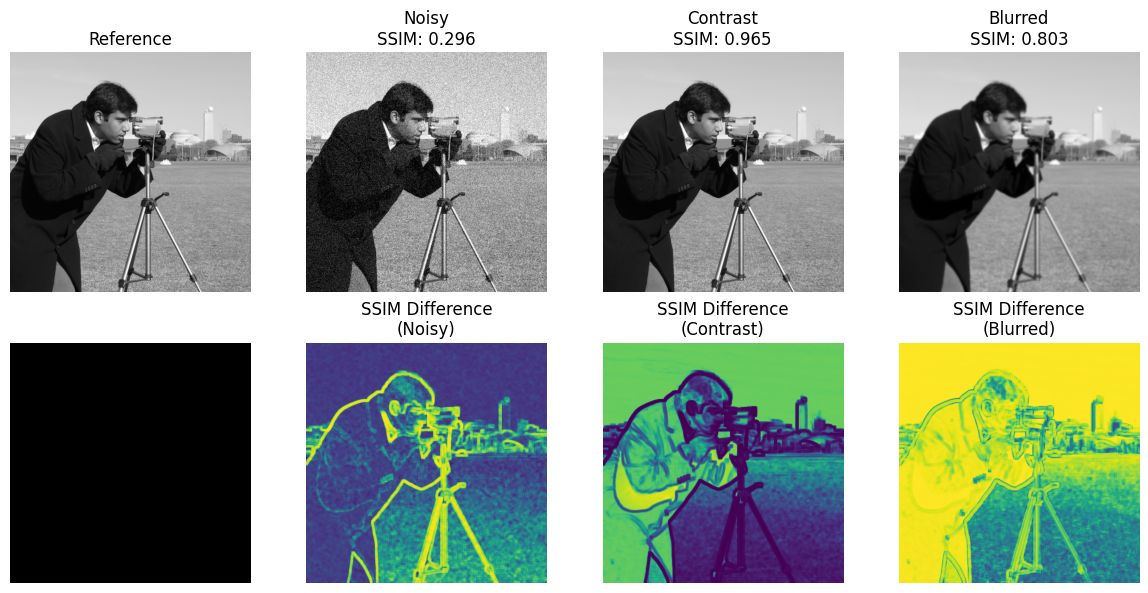

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra yang 'terdistorsi'
# a) Citra yang sama (SSIM harus 1)
image_same = image_ref.copy()

# b) Citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)

# c) Citra dengan kontras berbeda (contoh: dikalikan skalar)
image_contrast = np.clip(image_ref * 0.8, 0, 1)

# d) Citra yang di-blur
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None) # channel_axis=None jika grayscale

# 3. Hitung SSIM antara citra referensi dan citra terdistorsi
# SSIM memerlukan data_range (selisih nilai maksimum dan minimum piksel)
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)
# Parameter 'full=True' mengembalikan peta citra perbedaan SSIM juga

# 4. Tampilkan hasil SSIM dan citra perbedaan
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 5. Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Menampilkan peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off') # Placeholder untuk ruang kosong di bawah citra referensi

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Difference\n(Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Difference\n(Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Difference\n(Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()

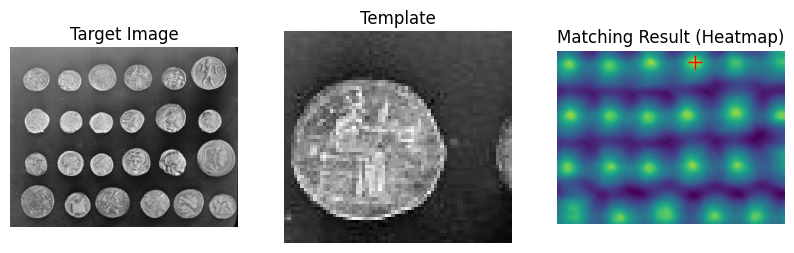

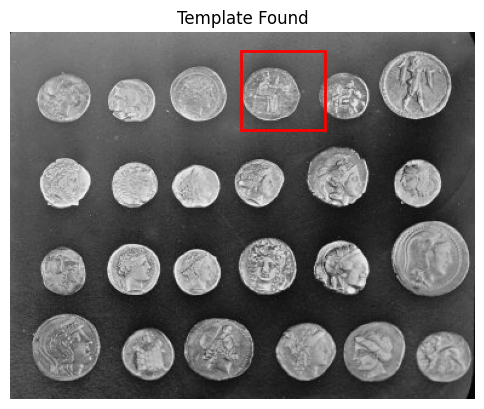

Template ditemukan di koordinat (x,y): (190, 15)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan buat/muat citra template
image = data.coins()
# Ambil salah satu koin sebagai template (sesuaikan koordinat jika perlu)
template = image[15:80, 190:260]

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation (metode default)
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
# np.argmax menemukan indeks linear, unravel_index mengubahnya ke koordinat 2D
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1] # Koordinat (x, y) dari sudut kiri atas template yang cocok

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

# Menampilkan heatmap hasil matching (opsional)
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()

# Tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10) # y, x karena ij adalah (row, col)

# Menampilkan kotak di lokasi terbaik pada citra asli (di plot terpisah agar lebih jelas)
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()

h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


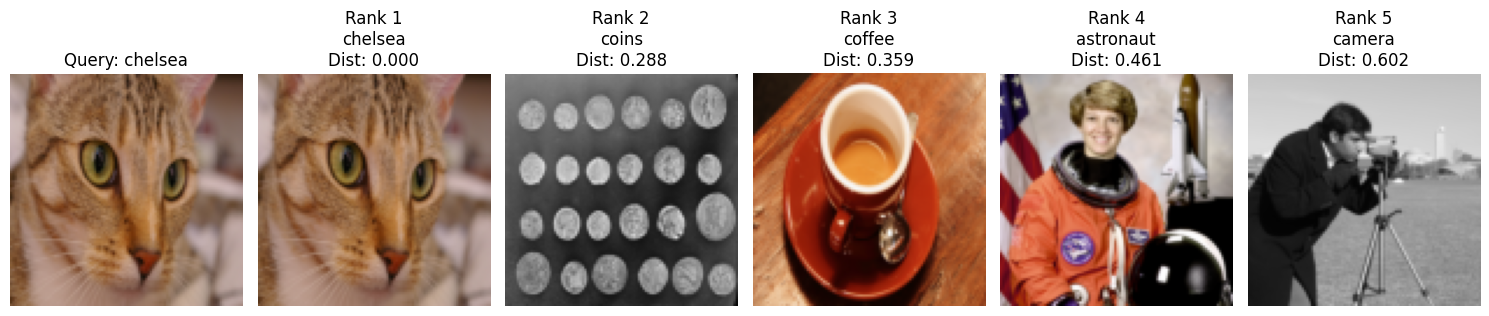

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram untuk ekstraksi fitur warna
def calculate_rgb_histogram(image, bins=16):
    # Pastikan input float [0,1] dikonversi ke uint8 [0,255] untuk histogram
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1 (Total jumlah menjadi 1)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined

# 1. Siapkan 'database' citra dan citra query
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        # Mengambil data gambar secara dinamis dari skimage.data
        img = getattr(data, name)()

        # Konversi ke RGB jika gambar grayscale
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar ukuran fitur konsisten (100x100)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)

        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih satu citra sebagai query (misal: 'chelsea' si kucing)
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 2. Hitung jarak (kemiripan) antara query dan database
# Menggunakan Cosine Distance (semakin kecil nilainya, semakin mirip)
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 3. Urutkan citra berdasarkan jarak (terkecil ke terbesar)
sorted_indices = np.argsort(distances)

# 4. Visualisasi Hasil
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan gambar Query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

# **PENUGASAN**

- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (Mean RGB + Euclidean Distance):
Rank 1: chelsea | Mean RGB: [147.7 111.4  86.8] | L2 Dist: 0.000
Rank 2: astronaut | Mean RGB: [141.6 105.8  96.5] | L2 Dist: 12.776
Rank 3: coffee | Mean RGB: [158.6  85.8  51.5] | L2 Dist: 45.003
Rank 4: camera | Mean RGB: [129.1 129.1 129.1] | L2 Dist: 49.416
Rank 5: coins | Mean RGB: [96.9 96.9 96.9] | L2 Dist: 53.809


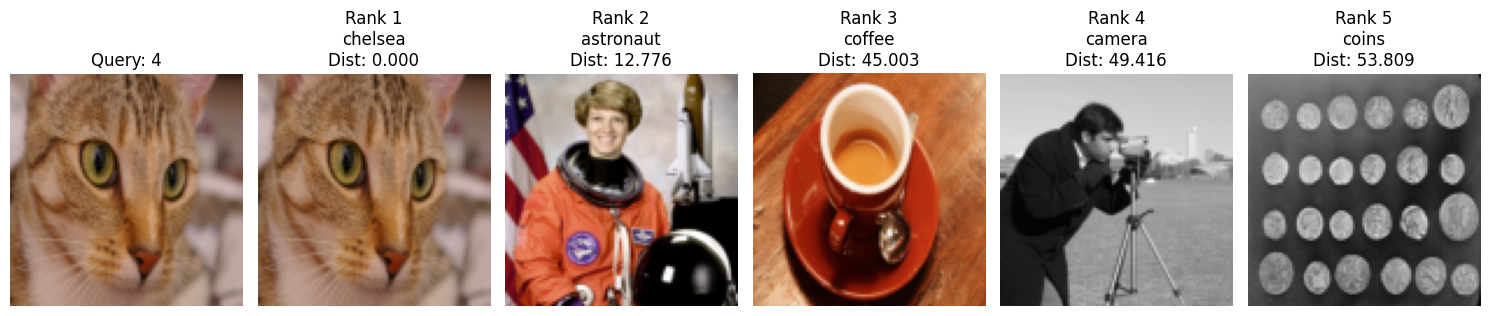

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from skimage.util import img_as_ubyte
from scipy.spatial import distance

def calculate_mean_rgb(image):
    img_uint8 = img_as_ubyte(image)
    mean_r = np.mean(img_uint8[:, :, 0])
    mean_g = np.mean(img_uint8[:, :, 1])
    mean_b = np.mean(img_uint8[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

# Siapkan database
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images, database_mean_feats = [], []

for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
    database_images.append(img_resized)
    database_mean_feats.append(calculate_mean_rgb(img_resized))
    print(f"- {name} diproses.")

# Query: chelsea
query_index = image_db_names.index("chelsea")
query_feat = database_mean_feats[query_index]

# Hitung Euclidean Distance
distances = []
for feat in database_mean_feats:
    dist = distance.euclidean(query_feat, feat)
    distances.append(dist)

sorted_indices = np.argsort(distances)

# Tampilkan hasil
print("\nHasil Retrieval (Mean RGB + Euclidean Distance):")
for i, idx in enumerate(sorted_indices):
    print(f"Rank {i+1}: {image_db_names[idx]} "
          f"| Mean RGB: {database_mean_feats[idx].round(1)} "
          f"| L2 Dist: {distances[idx]:.3f}")

# Visualisasi
fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))
axes[0].imshow(database_images[query_index])
axes[0].set_title(f"Query: {query_index}")
axes[0].axis('off')

for i, idx in enumerate(sorted_indices):
    axes[i + 1].imshow(database_images[idx])
    axes[i + 1].set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

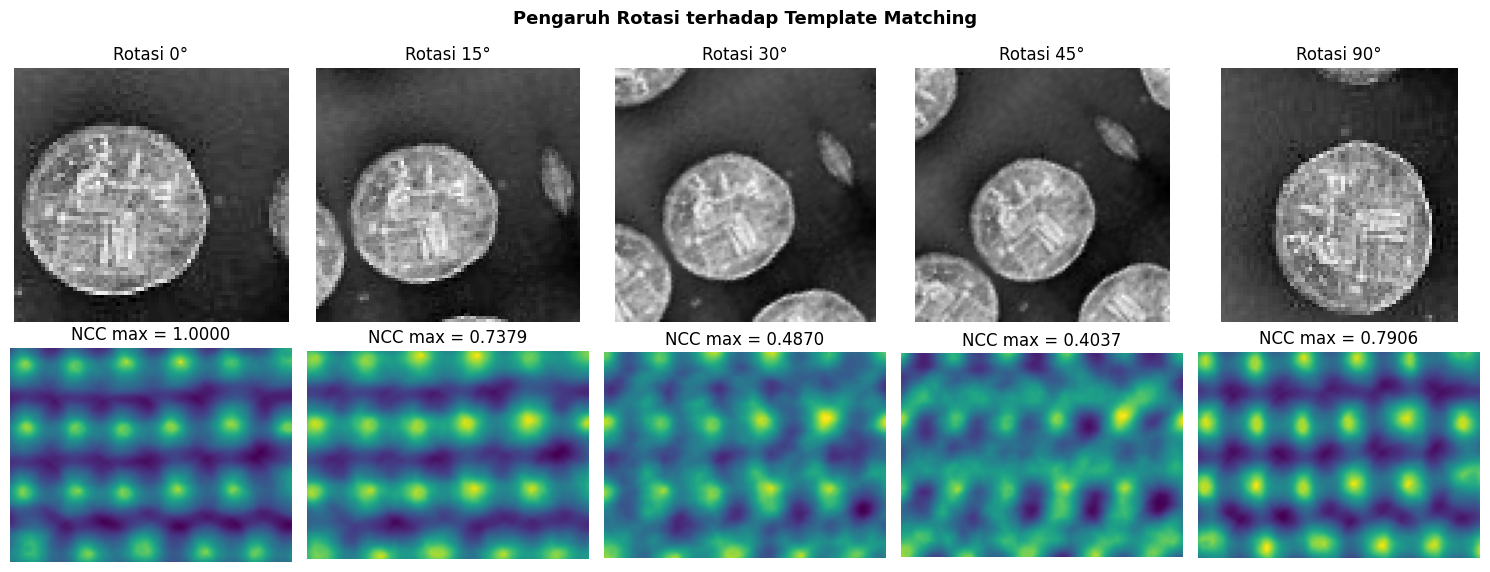

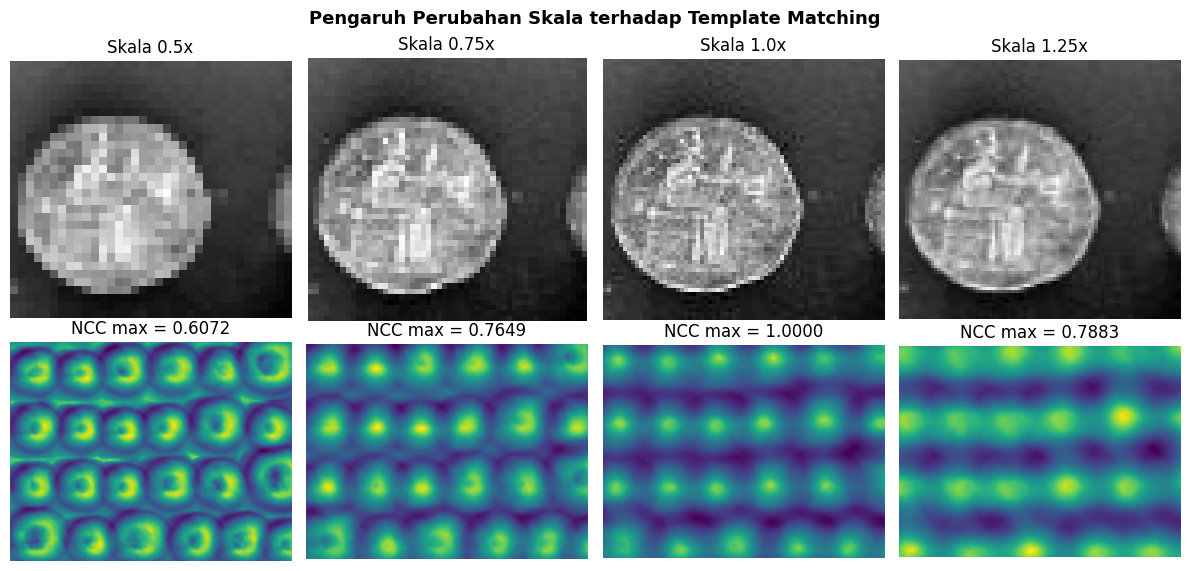

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage import transform as tf
from skimage.feature import match_template

image = data.coins()
template_orig = image[15:80, 190:260]

# =====================
# EKSPERIMEN ROTASI
# =====================
angles = [0, 15, 30, 45, 90]
fig, axes = plt.subplots(2, len(angles), figsize=(15, 6))

for i, angle in enumerate(angles):
    template_rotated = tf.rotate(template_orig, angle, resize=True, mode='reflect')

    if (template_rotated.shape[0] < image.shape[0] and
        template_rotated.shape[1] < image.shape[1]):
        result = match_template(image, template_rotated)
        ncc_max = result.max()
        ij = np.unravel_index(np.argmax(result), result.shape)
        x, y = ij[::-1]

        # Baris atas: template yang dirotasi
        axes[0][i].imshow(template_rotated, cmap='gray')
        axes[0][i].set_title(f'Rotasi {angle}°')
        axes[0][i].axis('off')

        # Baris bawah: heatmap hasil matching
        axes[1][i].imshow(result, cmap='viridis')
        axes[1][i].set_title(f'NCC max = {ncc_max:.4f}')
        axes[1][i].axis('off')

plt.suptitle('Pengaruh Rotasi terhadap Template Matching', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================
# EKSPERIMEN SKALA
# =====================
scale_factors = [0.5, 0.75, 1.0, 1.25]
fig2, axes2 = plt.subplots(2, len(scale_factors), figsize=(12, 6))

for i, scale in enumerate(scale_factors):
    template_scaled = tf.rescale(template_orig, scale, anti_aliasing=True, channel_axis=None)

    if (template_scaled.shape[0] < image.shape[0] and
        template_scaled.shape[1] < image.shape[1]):
        result = match_template(image, template_scaled)
        ncc_max = result.max()

        # Baris atas: template yang diubah skala
        axes2[0][i].imshow(template_scaled, cmap='gray')
        axes2[0][i].set_title(f'Skala {scale}x')
        axes2[0][i].axis('off')

        # Baris bawah: heatmap hasil matching
        axes2[1][i].imshow(result, cmap='viridis')
        axes2[1][i].set_title(f'NCC max = {ncc_max:.4f}')
        axes2[1][i].axis('off')

plt.suptitle('Pengaruh Perubahan Skala terhadap Template Matching', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()